teacher AUC (eval) = 0.7361 | features = 25 | N_REPEATS = 50
engine defined; conditions: ['Baseline', 'H2-only', 'H1-only', 'Full']
[saved] 03_temperature_matching.csv
selected T* (min es-ECE) = 1.0
[saved] 03_ablation_summary.csv
[saved] 03_gap_recovered.csv
additive-class gap (teacher - baseline) = +0.0089
[saved] 03_ablation_delong.csv
[saved] 03_path2_crosscheck.csv
[saved] 03_ablation_auc.png  &  03_ablation_auc.pdf


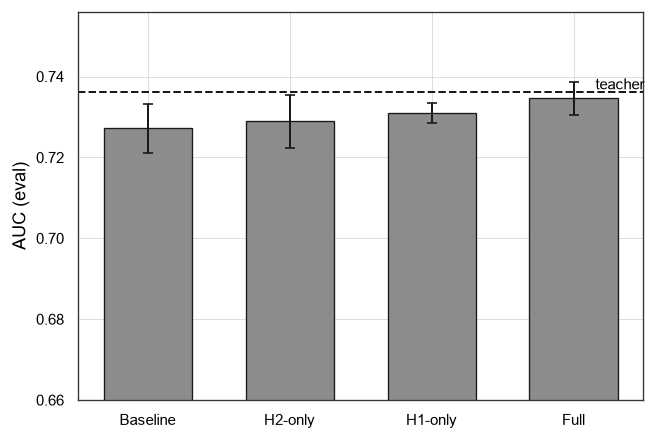

saved distilled_models.pkl with conditions: ['Baseline', 'H2-only', 'H1-only', 'Full']


In [1]:
# Notebook 03 — Distillation Engine & 2×2 Ablation (Track D)

import json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

import common as C
import config as CFG
C.set_grayscale_style()

X = pd.read_pickle(C.PROC_DIR / "X_all.pkl")
y = np.load(C.PROC_DIR / "y_all.npy")
SP = pickle.load(open(C.PROC_DIR / "splits.pkl", "rb"))
meta = json.load(open(C.PROC_DIR / "meta.json"))
FEATURES = meta["features"]
TP = np.load(C.PROC_DIR / "teacher_probs.npz")
pT = {k: TP[k] for k in TP.files}

Xtr, ytr = X.iloc[SP["train"]], y[SP["train"]]
Xes, yes = X.iloc[SP["es"]],   y[SP["es"]]
Xev, yev = X.iloc[SP["eval"]], y[SP["eval"]]
AUC_TEACHER = C.auc(yev, pT["eval"])

# ---- configuration (from config.py) -----------------------------------------
N_BINS      = CFG.N_BINS       # bins per feature for the controlled ablation
LAMBDA_MIX  = CFG.LAMBDA_MIX   # distill target = (1-λ) p^T + λ y
N_REPEATS   = CFG.N_REPEATS    # bootstrap repeats (design target = 50)
print(f"teacher AUC (eval) = {AUC_TEACHER:.4f} | features = {len(FEATURES)} "
      f"| N_REPEATS = {N_REPEATS}")


# ----------------------------------------------------------------------------
# DOF 2: build the boosting target
# ----------------------------------------------------------------------------
def temper(p, T):
    """Temperature on teacher probabilities via logits: T>1 softens."""
    return C.sigmoid(C.logit(p) / T)

def build_target(target_src, y_hard, p_teacher, lam=LAMBDA_MIX, T=1.0):
    if target_src == "hard":
        return y_hard.astype(float)
    pt = temper(p_teacher, T) if T != 1.0 else p_teacher
    return (1 - lam) * pt + lam * y_hard

# ----------------------------------------------------------------------------
# Common engine: depth-1 soft-logistic boosting with AUC early stopping on es
# ----------------------------------------------------------------------------
def xgb_stump_boost(Xtr_b, target, yes_hard, Xes_b, monotone=None,
                    eta=0.2, max_rounds=500, esr=30):
    dtrain = xgb.DMatrix(Xtr_b, label=target, feature_names=list(Xtr_b.columns))
    deval  = xgb.DMatrix(Xes_b, label=yes_hard, feature_names=list(Xes_b.columns))
    params = C.xgb_base_params(
        base_score=float(np.clip(np.mean(target), 1e-3, 1-1e-3)), eta=eta)
    if monotone is not None:
        params["monotone_constraints"] = "(" + ",".join(
            str(int(monotone.get(f, 0))) for f in Xtr_b.columns) + ")"
    bst = xgb.train(params, dtrain, num_boost_round=max_rounds,
                    evals=[(deval, "es")], early_stopping_rounds=esr,
                    verbose_eval=False)
    return bst

# ----------------------------------------------------------------------------
# One ablation condition -> a continuous scorecard (in ordinal-bin space)
# ----------------------------------------------------------------------------
def fit_condition(structure_src, target_src, Xtr_, ytr_, pT_tr,
                  lam=LAMBDA_MIX, T=1.0, monotone=None):
    method = "standard" if structure_src == "standard" else "TFM_induced"
    binning = C.fit_binning(Xtr_, pT_tr, FEATURES, n_bins=N_BINS, method=method)
    Xtr_b = C.apply_binning(Xtr_, binning)
    Xes_b = C.apply_binning(Xes, binning)
    target = build_target(target_src, ytr_, pT_tr, lam=lam, T=T)
    bst = xgb_stump_boost(Xtr_b, target, yes, Xes_b, monotone=monotone)
    sc = C.extract_scorecard_from_xgb(bst, list(Xtr_b.columns))
    return sc, binning

CONDITIONS = {
    "Baseline": ("standard",   "hard"),
    "H2-only":  ("TFM_induced","hard"),
    "H1-only":  ("standard",   "distill"),
    "Full":     ("TFM_induced","distill"),
}
print("engine defined; conditions:", list(CONDITIONS))


# ----------------------------------------------------------------------------
# Temperature control (double-distillation defense), tuned on split 2 (es)
#   The distilled student's probabilities must stay calibrated even though its
#   AUC stopping point is fixed elsewhere. We temper the teacher target by T and
#   pick T* minimizing the student's es-ECE (temperature scaling of the distill
#   target). This is a knob independent of AUC early stopping (C2 satisfied).
#   The entropy gap (design's softness-matching diagnostic) is reported too.
# ----------------------------------------------------------------------------
def bin_entropy(p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return float(np.mean(-(p*np.log(p) + (1-p)*np.log(1-p))))

T_GRID = [0.5, 0.75, 1.0, 1.25, 1.5, 2.0]
rows = []
for T in T_GRID:
    sc, binning = fit_condition("TFM_induced", "distill", Xtr, ytr, pT["train"], T=T)
    p_es = sc.predict_proba(C.apply_binning(Xes, binning))
    rows.append({"T": T,
                 "student_ECE_es": C.ece(yes, p_es),
                 "student_entropy_es": bin_entropy(p_es),
                 "teacher_target_entropy_es": bin_entropy(temper(pT["es"], T)),
                 "entropy_gap": abs(bin_entropy(p_es) - bin_entropy(temper(pT["es"], T)))})
temp_tbl = pd.DataFrame(rows)
T_STAR = float(temp_tbl.loc[temp_tbl["student_ECE_es"].idxmin(), "T"])
C.save_table(temp_tbl.round(5), "03_temperature_matching")
print("selected T* (min es-ECE) =", T_STAR)
temp_tbl.round(4)


# ----------------------------------------------------------------------------
# 2×2 ablation over bootstrap repeats  (eval metrics: AUC / ECE / reliability)
# ----------------------------------------------------------------------------
rng = np.random.default_rng(C.RANDOM_STATE)
Xev_cache = {}   # binning-specific discretized eval sets are rebuilt per fit
records = []
for rep in range(N_REPEATS):
    if rep == 0:
        idx = np.arange(len(Xtr))                       # full-data reference
    else:
        idx = rng.choice(len(Xtr), len(Xtr), replace=True)
    Xtr_r = Xtr.iloc[idx]; ytr_r = ytr[idx]; pT_r = pT["train"][idx]
    for name, (ssrc, tsrc) in CONDITIONS.items():
        T = T_STAR if tsrc == "distill" else 1.0
        sc, binning = fit_condition(ssrc, tsrc, Xtr_r, ytr_r, pT_r, T=T)
        Xev_b = C.apply_binning(Xev, binning)
        p_ev = sc.predict_proba(Xev_b)
        bm = C.brier_murphy(yev, p_ev, n_bins=10)
        records.append({"repeat": rep, "condition": name,
                        "AUC": C.auc(yev, p_ev), "ECE": C.ece(yev, p_ev),
                        "reliability": bm["reliability"],
                        "refinement": bm["refinement"]})
abl = pd.DataFrame(records)
summary = (abl[abl.repeat > 0].groupby("condition")
           .agg(AUC_mean=("AUC","mean"), AUC_std=("AUC","std"),
                ECE_mean=("ECE","mean"), ECE_std=("ECE","std"),
                reliability_mean=("reliability","mean"),
                refinement_mean=("refinement","mean"))
           .reindex(list(CONDITIONS)))
summary.insert(0, "AUC_teacher", AUC_TEACHER)
C.save_table(summary.round(5).reset_index(), "03_ablation_summary")
summary.round(4)


# ----------------------------------------------------------------------------
# RQ4-2 headline: fraction of the teacher gap recovered by each component
#   recovered = (AUC_cond - AUC_baseline) / (AUC_teacher - AUC_baseline)
# ----------------------------------------------------------------------------
base_auc = summary.loc["Baseline", "AUC_mean"]
gap = AUC_TEACHER - base_auc
frac = ((summary["AUC_mean"] - base_auc) / gap).rename("gap_recovered_frac")
recovered = pd.concat([summary["AUC_mean"], frac], axis=1)
recovered.loc["Teacher"] = [AUC_TEACHER, 1.0]
C.save_table(recovered.round(5).reset_index(), "03_gap_recovered")
print(f"additive-class gap (teacher - baseline) = {gap:+.4f}")
recovered.round(4)


# ----------------------------------------------------------------------------
# DeLong paired tests on the full-data (repeat 0) fits: each condition vs Baseline
# ----------------------------------------------------------------------------
preds = {}
for name, (ssrc, tsrc) in CONDITIONS.items():
    T = T_STAR if tsrc == "distill" else 1.0
    sc, binning = fit_condition(ssrc, tsrc, Xtr, ytr, pT["train"], T=T)
    preds[name] = sc.predict_proba(C.apply_binning(Xev, binning))

dl_rows = []
for name in ["H2-only", "H1-only", "Full"]:
    d = C.delong_test(yev, preds[name], preds["Baseline"])
    dl_rows.append({"comparison": f"{name} vs Baseline", "AUC_a": d["auc1"],
                    "AUC_b": d["auc2"], "diff": d["diff"],
                    "z": d["z"], "p_value": d["p_value"]})
d = C.delong_test(yev, preds["Full"], preds["H1-only"])
dl_rows.append({"comparison": "Full vs H1-only", "AUC_a": d["auc1"],
                "AUC_b": d["auc2"], "diff": d["diff"], "z": d["z"],
                "p_value": d["p_value"]})
delong_tbl = pd.DataFrame(dl_rows)
C.save_table(delong_tbl.round(5), "03_ablation_delong")
delong_tbl.round(4)


# ----------------------------------------------------------------------------
# Path 2 (score refit) cross-check: fix Full structure, set each bin's score to
# the empirical logit of the mean TEACHER probability in that bin (closed form).
# If path 1 and path 2 agree, the ablation is not an artifact of the boosting.
# ----------------------------------------------------------------------------
def path2_refit(binning, Xtr_, pT_tr):
    Xb = C.apply_binning(Xtr_, binning)
    features = list(Xb.columns)
    edges = {f: np.arange(0.5, np.nanmax(Xb[f].to_numpy()) + 1.0) for f in features}
    contribs, missing = {}, {}
    obar = np.clip(pT_tr.mean(), 1e-4, 1-1e-4); base = C.logit(np.array([obar]))[0]
    for f in features:
        b = Xb[f].to_numpy()
        nb = int(np.nanmax(b)) + 1
        c = np.zeros(nb)
        for k in range(nb):
            m = (b == k)
            c[k] = C.logit(np.array([np.clip(pT_tr[m].mean(), 1e-4, 1-1e-4)]))[0] - base if m.sum() else 0.0
        contribs[f] = c
        mmask = np.isnan(b)
        missing[f] = (C.logit(np.array([np.clip(pT_tr[mmask].mean(),1e-4,1-1e-4)]))[0]-base) if mmask.sum() else 0.0
    return C.Scorecard(base, features, edges, contribs, missing)

_, binning_full = fit_condition("TFM_induced", "distill", Xtr, ytr, pT["train"], T=T_STAR)
sc_p2 = path2_refit(binning_full, Xtr, pT["train"])
p_p2 = sc_p2.predict_proba(C.apply_binning(Xev, binning_full))
xcheck = pd.DataFrame([{
    "AUC_path1_Full": C.auc(yev, preds["Full"]),
    "AUC_path2_refit": C.auc(yev, p_p2),
    "ECE_path1_Full": C.ece(yev, preds["Full"]),
    "ECE_path2_refit": C.ece(yev, p_p2),
    "pred_corr": float(np.corrcoef(preds["Full"], p_p2)[0, 1]),
}])
C.save_table(xcheck.round(5), "03_path2_crosscheck")
xcheck.round(4)


# ----------------------------------------------------------------------------
# Figure: ablation AUC with teacher upper bound (grayscale, bootstrap error bars)
# ----------------------------------------------------------------------------
order = list(CONDITIONS)
means = summary.loc[order, "AUC_mean"].to_numpy()
stds  = summary.loc[order, "AUC_std"].to_numpy()
fig, ax = plt.subplots(figsize=(5.6, 3.8))
xpos = np.arange(len(order))
ax.bar(xpos, means, yerr=stds, capsize=3, color="#8c8c8c",
       edgecolor="#1a1a1a", linewidth=0.8, width=0.62)
ax.axhline(AUC_TEACHER, color="#1a1a1a", linestyle="--", linewidth=1.2)
ax.text(len(order)-0.5, AUC_TEACHER, " teacher", va="bottom", ha="right",
        fontsize=9)
ax.set_xticks(xpos); ax.set_xticklabels(order)
ax.set_ylabel("AUC (eval)")
ax.set_ylim(min(means.min(), 0.68) - 0.02, AUC_TEACHER + 0.02)
fig.tight_layout()
C.save_fig(fig, "03_ablation_auc")
plt.show()


# ----------------------------------------------------------------------------
# Persist the four representative (full-data) scorecards + binnings for reuse
# ----------------------------------------------------------------------------
store = {}
for name, (ssrc, tsrc) in CONDITIONS.items():
    T = T_STAR if tsrc == "distill" else 1.0
    sc, binning = fit_condition(ssrc, tsrc, Xtr, ytr, pT["train"], T=T)
    store[name] = {"scorecard": sc, "binning": binning,
                   "structure": ssrc, "target": tsrc, "T": T}
with open(C.PROC_DIR / "distilled_models.pkl", "wb") as fh:
    pickle.dump(store, fh)
print("saved distilled_models.pkl with conditions:", list(store))
